In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

file_path = '/content/drive/MyDrive/Colab Notebooks/fmcg_sales_2024.csv'
df = pd.read_csv(file_path)
display(df.head())

,Transaction_ID,Date,Region,City,Sales_Channel,Product_Category,Product_Name,Units_Sold,Selling_Price,Unit_Cost,Revenue,Cost,Profit,Customer_Type
0,TXN-0001,2024-01-03,Banten,Tangerang,General Trade,Milk,Premium Whole Milk 1L,34,23000,20500,782000,697000,85000,Retail
1,TXN-0002,2024-01-03,Banten,Tangerang,Modern Trade,Milk,Premium Whole Milk 1L,24,25000,22500,600000,540000,60000,Retail
2,TXN-0003,2024-01-03,Jakarta,Jakarta Selatan,General Trade,Milk,Chocolate 1L,12,21500,18500,258000,222000,36000,Retail
3,TXN-0004,2024-01-03,East Java,Malang,Distributor,Yoghurt,Cimory Plain Yoghurt 400g,193,18500,15500,3570500,2991500,579000,Institution
4,TXN-0005,2024-01-03,Sumatera,Padang,General Trade,Nugget,Fiesta Crispy Nugget 400g,37,39000,33000,1443000,1221000,222000,Retail


### Periksa Missing Values

Kita akan memeriksa apakah ada nilai yang hilang (missing values) di setiap kolom DataFrame.

In [ ]:
# Periksa missing values
missing_values = df.isnull().sum()
display(missing_values[missing_values > 0])

if missing_values.sum() == 0:
    print("Tidak ada nilai yang hilang dalam DataFrame.")
else:
    print("Ada nilai yang hilang dalam DataFrame. Detail di atas.")

,0


Tidak ada nilai yang hilang dalam DataFrame.


### Ringkasan Statistik DataFrame

Kita akan menampilkan ringkasan statistik deskriptif dari kolom-kolom numerik dalam DataFrame `df`.

In [ ]:
# Tampilkan ringkasan statistik dengan format yang lebih mudah dibaca
pd.options.display.float_format = '{:,.0f}'.format
display(df.describe())
pd.options.display.float_format = None # Reset to default for future operations

,Units_Sold,Selling_Price,Unit_Cost,Revenue,Cost,Profit
count,"1,500","1,500","1,500","1,500","1,500","1,500"
mean,69,"25,205","20,489","1,722,349","1,399,354","322,995"
std,64,"14,980","11,797","2,155,328","1,731,242","447,405"
min,7,"4,000","3,500","40,000","35,000","4,000"
25%,28,"17,000","13,000","499,625","408,000","84,000"
50%,45,"23,500","19,250","1,000,000","820,000","172,000"
75%,76,"32,000","25,000","1,947,125","1,584,000","370,000"
max,361,"83,500","64,000","17,762,500","14,210,000","3,875,000"


In [ ]:
df['Profit_Margin_%'] = (df['Profit'] / df['Revenue']) * 100

# Summary Performa Produk
descriptive_summary = df.groupby('Product_Category').agg(
    Total_Units_Sold=('Units_Sold', 'sum'),
    Total_Revenue=('Revenue', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Avg_Margin_Percent=('Profit_Margin_%', 'mean')
).reset_index().sort_values(by='Total_Revenue', ascending=False)

print("--- DESCRIPTIVE ANALYTICS: PRODUCT PERFORMANCE ---")
display(descriptive_summary)

--- DESCRIPTIVE ANALYTICS: PRODUCT PERFORMANCE ---


,Product_Category,Total_Units_Sold,Total_Revenue,Total_Profit,Avg_Margin_Percent
3,Sausage,21576,695620000,150708000,22
0,Cheese,15592,571759000,140069000,25
2,Nugget,14525,528553500,78973500,15
1,Milk,29412,458217500,57153500,12
4,Yoghurt,21987,329374000,57588500,17


# Revenue & Profitability Core

In [ ]:
# Hitung total Revenue per produk
product_revenue = df.groupby('Product_Name')['Revenue'].sum().reset_index()

# Urutkan berdasarkan Revenue dan ambil 10 teratas
top_10_products = product_revenue.sort_values(by='Revenue', ascending=False).head(10)

# Hitung total Revenue keseluruhan
total_revenue = df['Revenue'].sum()

# Hitung kontribusi persentase untuk setiap produk Top 10
top_10_products['Contribution (%)'] = (top_10_products['Revenue'] / total_revenue) * 100

# Format kolom Revenue dan Contribution (%) untuk tampilan yang lebih baik
top_10_products['Revenue'] = top_10_products['Revenue'].apply(lambda x: f"Rp {x:,.0f}")
top_10_products['Contribution (%)'] = top_10_products['Contribution (%)'].apply(lambda x: f"{x:.2f}%")

# Tampilkan hasil
print("Top 10 Produk berdasarkan Revenue dan Kontribusinya:")
display(top_10_products.reset_index(drop=True))

Top 10 Produk berdasarkan Revenue dan Kontribusinya:


,Product_Name,Revenue,Contribution (%)
0,So Good Chicken Sausage 375g,"Rp 241,238,500",9.34%
1,Anchor Cheddar Block 500g,"Rp 235,549,500",9.12%
2,Bernardi Beef Sausage 500g,"Rp 166,316,000",6.44%
3,Kraft Cheddar Cheese 165g,"Rp 160,443,500",6.21%
4,So Good Chicken Nugget 500g,"Rp 150,592,000",5.83%
5,Premium Whole Milk 1L,"Rp 147,556,000",5.71%
6,Fiesta Crispy Nugget 400g,"Rp 143,694,500",5.56%
7,Chocolate 1L,"Rp 129,779,000",5.02%
8,Cimory Full Cream 1L,"Rp 122,057,500",4.72%
9,Kimbo Beef Sausage 375g,"Rp 103,289,500",4.00%


In [ ]:
# Hitung total Profit per produk
product_profit = df.groupby('Product_Name')['Profit'].sum().reset_index()

# Urutkan berdasarkan Profit dan ambil 10 teratas
top_10_products_by_profit = product_profit.sort_values(by='Profit', ascending=False).head(10)

# Hitung total Profit keseluruhan
total_profit = df['Profit'].sum()

# Hitung kontribusi persentase untuk setiap produk Top 10
top_10_products_by_profit['Contribution (%)'] = (top_10_products_by_profit['Profit'] / total_profit) * 100

# Format kolom Profit dan Contribution (%) untuk tampilan yang lebih baik
top_10_products_by_profit['Profit'] = top_10_products_by_profit['Profit'].apply(lambda x: f"Rp {x:,.0f}")
top_10_products_by_profit['Contribution (%)'] = top_10_products_by_profit['Contribution (%)'].apply(lambda x: f"{x:.2f}%")

# Tampilkan hasil
print("Top 10 Produk berdasarkan Gross Profit dan Kontribusinya:")
display(top_10_products_by_profit.reset_index(drop=True))

Top 10 Produk berdasarkan Gross Profit dan Kontribusinya:


,Product_Name,Profit,Contribution (%)
0,Anchor Cheddar Block 500g,"Rp 54,587,000",11.27%
1,So Good Chicken Sausage 375g,"Rp 53,515,500",11.05%
2,Kraft Cheddar Cheese 165g,"Rp 40,695,500",8.40%
3,Bernardi Beef Sausage 500g,"Rp 35,084,500",7.24%
4,So Good Chicken Nugget 500g,"Rp 22,627,000",4.67%
5,Farmhouse Sausage 250g,"Rp 22,465,000",4.64%
6,Kimbo Beef Sausage 375g,"Rp 21,870,500",4.51%
7,Fiesta Crispy Nugget 400g,"Rp 21,053,000",4.35%
8,Premium Whole Milk 1L,"Rp 17,989,500",3.71%
9,Prochiz Gold Slices 150g,"Rp 17,884,000",3.69%


In [ ]:
# CODE UNTUK DIAGNOSTIC ANALYTICS
diagnostic_channel = df.groupby(['Product_Category', 'Sales_Channel']).agg(
    Avg_Selling_Price=('Selling_Price', 'mean'),
    Avg_Unit_Cost=('Unit_Cost', 'mean'),
    Avg_Margin=('Profit_Margin_%', 'mean')
).reset_index()

print("--- DIAGNOSTIC ANALYTICS: WHY DO MARGINS VARY BY CHANNEL? ---")
display(diagnostic_channel)

--- DIAGNOSTIC ANALYTICS: WHY DO MARGINS VARY BY CHANNEL? ---


,Product_Category,Sales_Channel,Avg_Selling_Price,Avg_Unit_Cost,Avg_Margin
0,Cheese,Distributor,38148.936170,29053.191489,24.613028
1,Cheese,General Trade,35433.333333,26461.904762,25.246015
2,Cheese,Modern Trade,33664.634146,25378.048780,24.782802
3,Milk,Distributor,15321.100917,13366.972477,12.803696
4,Milk,General Trade,16283.018868,14292.452830,12.000457
5,Milk,Modern Trade,16306.666667,14333.333333,11.818925
6,Nugget,Distributor,36940.000000,31420.000000,14.927701
7,Nugget,General Trade,36077.777778,30650.000000,15.109929
8,Nugget,Modern Trade,36111.111111,30746.913580,14.863371
9,Sausage,Distributor,32227.272727,25220.779221,21.752233


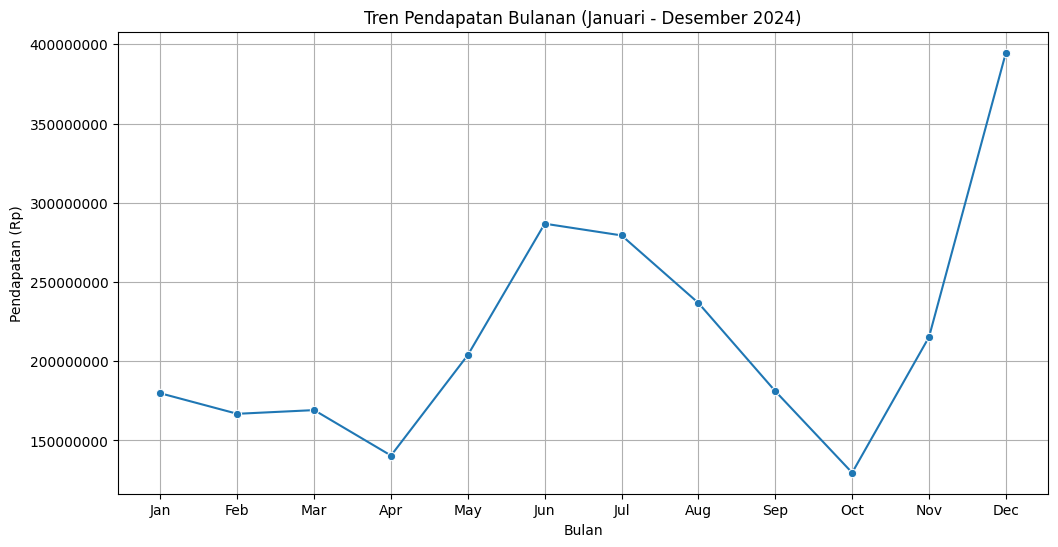


Bulan dengan pendapatan tertinggi (Peak Season) adalah Dec dengan total pendapatan Rp 394,668,000.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Pastikan kolom 'Date' dalam format datetime
df['Date'] = pd.to_datetime(df['Date'])

# Ekstrak bulan dan tahun
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

# Filter data untuk tahun 2024 jika ada data multi-tahun
df_2024 = df[df['Year'] == 2024]

# Hitung total Revenue bulanan
monthly_revenue = df_2024.groupby('Month')['Revenue'].sum().reset_index()

# Urutkan berdasarkan bulan
monthly_revenue = monthly_revenue.sort_values(by='Month')

# Konversi nomor bulan menjadi nama bulan untuk visualisasi
month_names = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
               7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
monthly_revenue['Month_Name'] = monthly_revenue['Month'].map(month_names)

# Visualisasi tren pendapatan bulanan
plt.figure(figsize=(12, 6))
sns.lineplot(x='Month_Name', y='Revenue', data=monthly_revenue, marker='o')
plt.title('Tren Pendapatan Bulanan (Januari - Desember 2024)')
plt.xlabel('Bulan')
plt.ylabel('Pendapatan (Rp)')
plt.grid(True)
plt.ticklabel_format(style='plain', axis='y') # Menghilangkan notasi ilmiah pada sumbu y
plt.show()

# Identifikasi peak season (bulan dengan pendapatan tertinggi)
peak_revenue = monthly_revenue.loc[monthly_revenue['Revenue'].idxmax()]
print(f"\nBulan dengan pendapatan tertinggi (Peak Season) adalah {peak_revenue['Month_Name']} dengan total pendapatan Rp {peak_revenue['Revenue']:,.0f}.")

# Jika ada bulan lain dengan pendapatan mendekati puncak, bisa juga dipertimbangkan

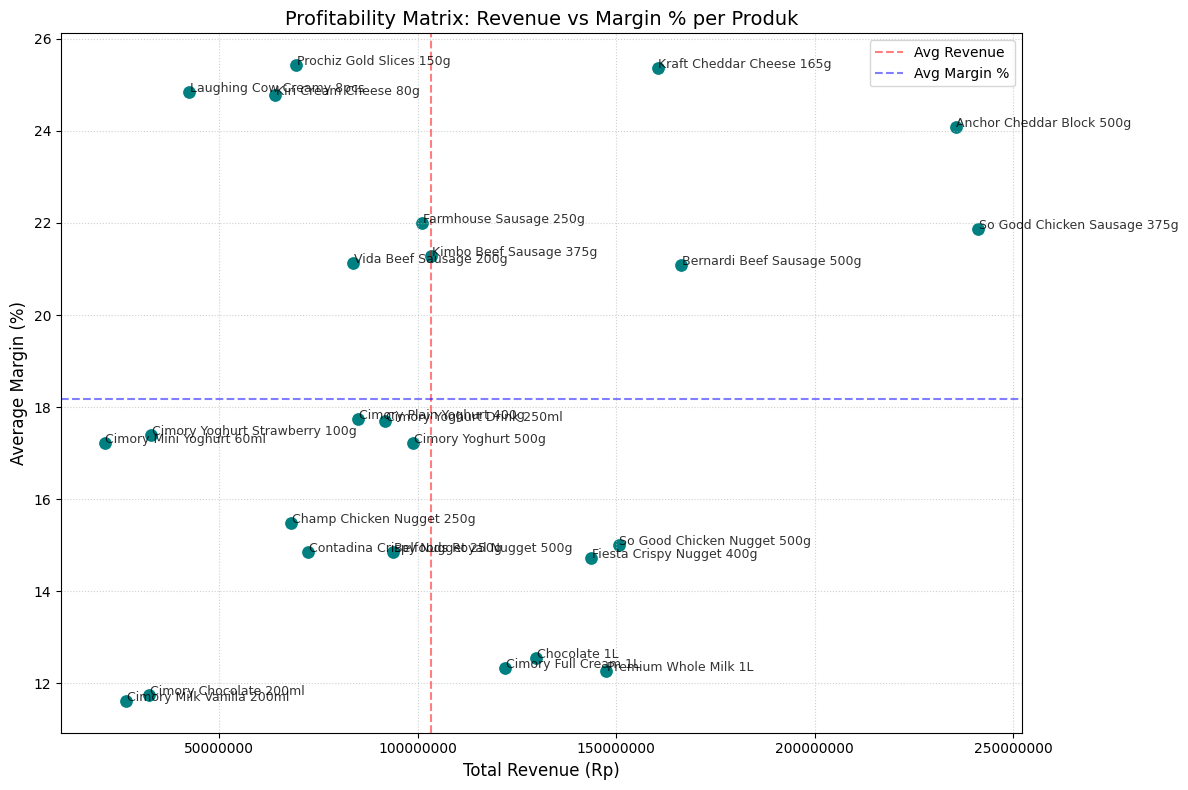

In [ ]:
# Hitung metrik per produk: Total Revenue dan Average Margin %
df['Margin_Pct'] = (df['Profit'] / df['Revenue']) * 100
product_matrix = df.groupby('Product_Name').agg({
    'Revenue': 'sum',
    'Margin_Pct': 'mean'
}).reset_index()

# Visualisasi Profitability Matrix
plt.figure(figsize=(12, 8))
sns.scatterplot(data=product_matrix, x='Revenue', y='Margin_Pct', s=100, color='teal')

# Tambahkan label untuk setiap titik (nama produk)
for i in range(product_matrix.shape[0]):
    plt.text(product_matrix.Revenue[i]+200000, product_matrix.Margin_Pct[i],
             product_matrix.Product_Name[i], fontsize=9, alpha=0.8)

# Tambahkan garis rata-rata untuk membantu analisis kuadran
plt.axvline(product_matrix['Revenue'].mean(), color='red', linestyle='--', alpha=0.5, label='Avg Revenue')
plt.axhline(product_matrix['Margin_Pct'].mean(), color='blue', linestyle='--', alpha=0.5, label='Avg Margin %')

plt.title('Profitability Matrix: Revenue vs Margin % per Produk', fontsize=14)
plt.xlabel('Total Revenue (Rp)', fontsize=12)
plt.ylabel('Average Margin (%)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.ticklabel_format(style='plain', axis='x')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# CODE UNTUK PREDICTIVE ANALYTICS (Forecasting Sederhana berbasis Tren Bulanan)
import numpy as np
from sklearn.linear_model import LinearRegression

df['Date'] = pd.to_datetime(df['Date'])
df['Month_Num'] = df['Date'].dt.month

# Kelompokkan revenue berdasarkan bulan berjalan
monthly_revenue = df.groupby('Month_Num')['Revenue'].sum().reset_index()

# Siapkan model Linear Regression untuk melihat tren ke depan
X = monthly_revenue[['Month_Num']]
y = monthly_revenue['Revenue']

model = LinearRegression()
model.fit(X, y)

# Prediksi untuk Bulan 13, 14, 15 (Kuartal berikutnya di tahun depan)
# Menggunakan DataFrame untuk menghindari UserWarning terkait feature names
future_months = pd.DataFrame({'Month_Num': [13, 14, 15]})
predictions = model.predict(future_months)

print("--- PREDICTIVE ANALYTICS: REVENUE FORECAST NEXT QUARTER ---")
for m, pred in zip([1, 2, 3], predictions):
    print(f"Prediksi Revenue Bulan ke-{m} Tahun Depan: Rp {pred:,.0f}")

--- PREDICTIVE ANALYTICS: REVENUE FORECAST NEXT QUARTER ---
Prediksi Revenue Bulan ke-1 Tahun Depan: Rp 279,339,576
Prediksi Revenue Bulan ke-2 Tahun Depan: Rp 289,192,793
Prediksi Revenue Bulan ke-3 Tahun Depan: Rp 299,046,009


# Regional Performance

In [ ]:
# Hitung total Revenue per Region
region_revenue = df.groupby('Region')['Revenue'].sum().reset_index()

# Urutkan berdasarkan Revenue untuk mendapatkan ranking
region_ranking = region_revenue.sort_values(by='Revenue', ascending=False)

# Hitung total Revenue keseluruhan
total_rev_all = df['Revenue'].sum()

# Hitung kontribusi persentase per wilayah
region_ranking['Contribution (%)'] = (region_ranking['Revenue'] / total_rev_all) * 100

# Format tampilan
region_ranking_display = region_ranking.copy()
region_ranking_display['Revenue'] = region_ranking_display['Revenue'].apply(lambda x: f"Rp {x:,.0f}")
region_ranking_display['Contribution (%)'] = region_ranking_display['Contribution (%)'].apply(lambda x: f"{x:.2f}%")

print("Peringkat Wilayah Berdasarkan Revenue dan Kontribusinya:")
display(region_ranking_display.reset_index(drop=True))

Peringkat Wilayah Berdasarkan Revenue dan Kontribusinya:


,Region,Revenue,Contribution (%)
0,Jakarta,"Rp 531,247,500",20.56%
1,West Java,"Rp 410,571,000",15.89%
2,Central Java,"Rp 324,115,000",12.55%
3,East Java,"Rp 312,803,500",12.11%
4,Sumatera,"Rp 231,373,000",8.96%
5,Kalimantan,"Rp 186,348,500",7.21%
6,Banten,"Rp 179,652,000",6.95%
7,Bali,"Rp 154,602,500",5.98%
8,Sulawesi,"Rp 139,861,000",5.41%
9,Yogyakarta,"Rp 112,950,000",4.37%


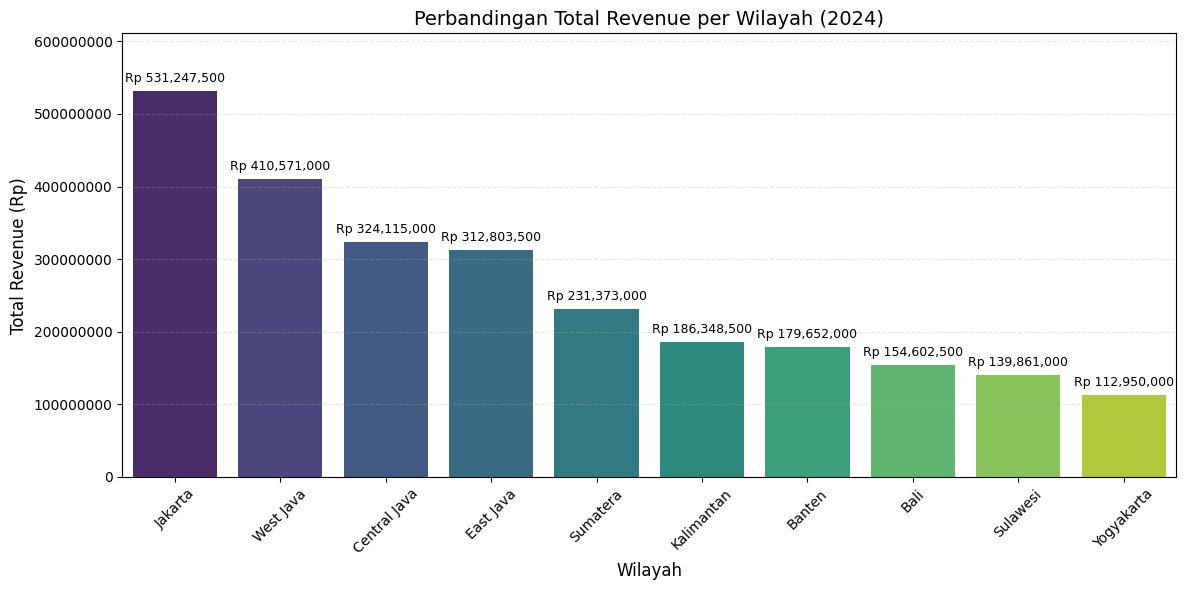

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualisasi Pendapatan per Wilayah
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=region_ranking, x='Region', y='Revenue', palette='viridis', hue='Region', legend=False)

# Menambahkan label nilai pada setiap batang
for p in ax.patches:
    ax.annotate(f'Rp {p.get_height():,.0f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points',
                fontsize=9)

plt.title('Perbandingan Total Revenue per Wilayah (2024)', fontsize=14)
plt.xlabel('Wilayah', fontsize=12)
plt.ylabel('Total Revenue (Rp)', fontsize=12)
plt.xticks(rotation=45)
plt.ticklabel_format(style='plain', axis='y')
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Memberikan ruang lebih di atas untuk label
plt.ylim(0, region_ranking['Revenue'].max() * 1.15)

plt.tight_layout()
plt.show()

Total Revenue per Region (Kuartal):


Quarter,2024Q1,2024Q2,2024Q3,2024Q4
Region,,,,
Bali,"Rp 22,905,500","Rp 31,282,000","Rp 53,853,500","Rp 46,561,500"
Banten,"Rp 34,481,500","Rp 60,850,500","Rp 47,428,500","Rp 36,891,500"
Central Java,"Rp 67,018,000","Rp 64,924,500","Rp 73,220,500","Rp 118,952,000"
East Java,"Rp 72,431,000","Rp 73,302,000","Rp 85,854,500","Rp 81,216,000"
Jakarta,"Rp 130,224,500","Rp 98,377,500","Rp 139,229,500","Rp 163,416,000"
Kalimantan,"Rp 39,540,500","Rp 65,898,000","Rp 25,063,500","Rp 55,846,500"
Sulawesi,"Rp 21,927,000","Rp 31,426,000","Rp 51,188,500","Rp 35,319,500"
Sumatera,"Rp 39,836,500","Rp 52,056,500","Rp 84,311,500","Rp 55,168,500"
West Java,"Rp 63,062,000","Rp 110,224,500","Rp 120,739,000","Rp 116,545,500"



Pertumbuhan QoQ per Region (%):


Quarter,2024Q1,2024Q2,2024Q3,2024Q4
Region,,,,
Bali,-,36.57%,72.15%,-13.54%
Banten,-,76.47%,-22.06%,-22.22%
Central Java,-,-3.12%,12.78%,62.46%
East Java,-,1.20%,17.12%,-5.40%
Jakarta,-,-24.46%,41.53%,17.37%
Kalimantan,-,66.66%,-61.97%,122.82%
Sulawesi,-,43.32%,62.89%,-31.00%
Sumatera,-,30.68%,61.96%,-34.57%
West Java,-,74.79%,9.54%,-3.47%


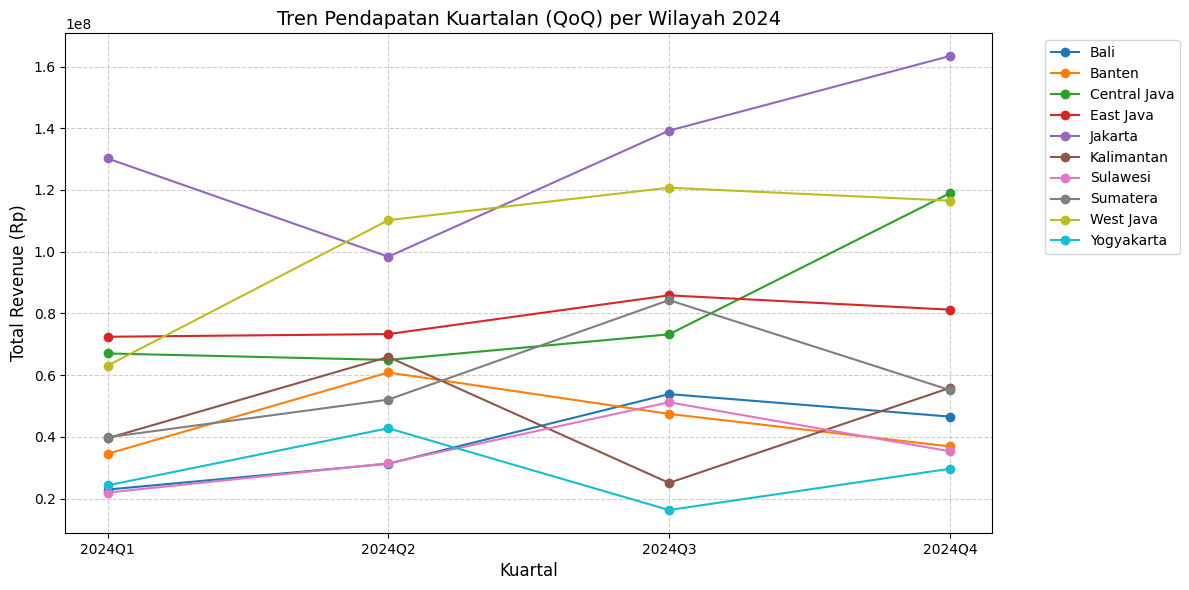

In [ ]:
# Ekstrak Kuartal dari kolom Date
df['Quarter'] = df['Date'].dt.to_period('Q').astype(str)

# Agregasi Revenue berdasarkan Region dan Quarter
regional_qoq = df.groupby(['Region', 'Quarter'])['Revenue'].sum().unstack()

# Hitung Pertumbuhan QoQ (%) dengan axis=1 (columns)
qoq_growth = regional_qoq.pct_change(axis=1) * 100

# Format tampilan
print("Total Revenue per Region (Kuartal):")
display(regional_qoq.style.format("Rp {:,.0f}"))

print("\nPertumbuhan QoQ per Region (%):")
display(qoq_growth.style.format("{:,.2f}%", na_rep="-")\
    .background_gradient(cmap='RdYlGn', axis=None, low=0.5, high=0.5))

# Visualisasi Tren QoQ
plt.figure(figsize=(12, 6))
for region in regional_qoq.index:
    plt.plot(regional_qoq.columns, regional_qoq.loc[region], marker='o', label=region)

plt.title('Tren Pendapatan Kuartalan (QoQ) per Wilayah 2024', fontsize=14)
plt.xlabel('Kuartal', fontsize=12)
plt.ylabel('Total Revenue (Rp)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

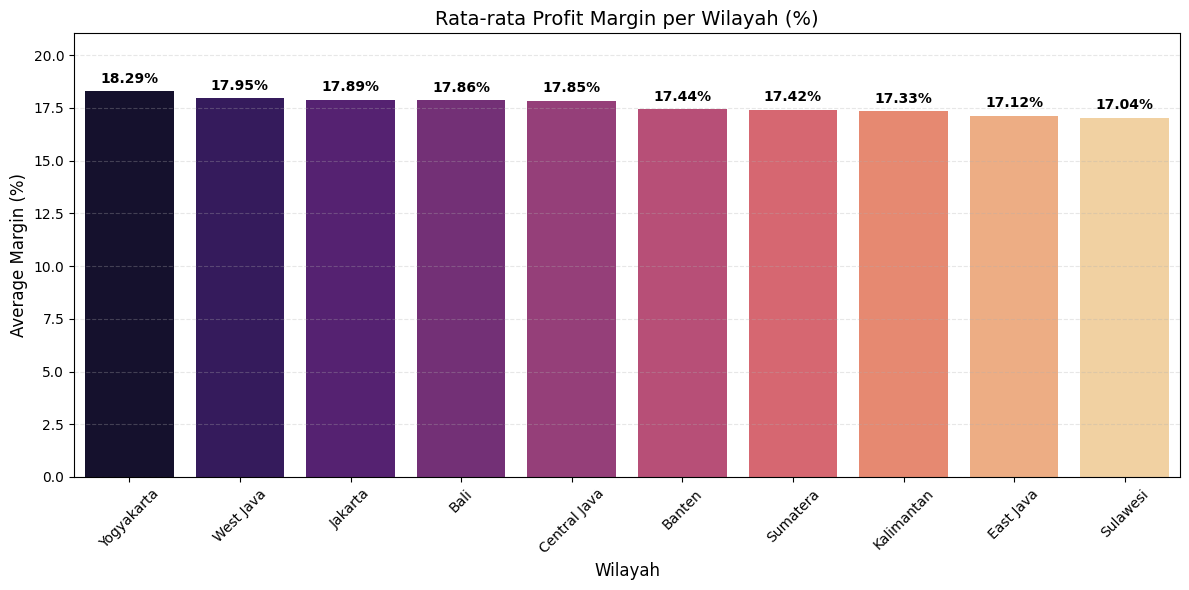

In [ ]:
# Hitung Average Margin per Region
region_margin = df.groupby('Region')['Margin_Pct'].mean().reset_index()
region_margin = region_margin.sort_values(by='Margin_Pct', ascending=False)

# Visualisasi Profit Margin per Wilayah
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=region_margin, x='Region', y='Margin_Pct', palette='magma', hue='Region', legend=False)

# Tambahkan label nilai persentase
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=10, weight='bold')

plt.title('Rata-rata Profit Margin per Wilayah (%)', fontsize=14)
plt.xlabel('Wilayah', fontsize=12)
plt.ylabel('Average Margin (%)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Memberikan ruang untuk label
plt.ylim(0, region_margin['Margin_Pct'].max() * 1.15)

plt.tight_layout()
plt.show()

# Channel Analysis

Summary Sales Channel Performance:


,Sales_Channel,Revenue,Profit
0,Distributor,"Rp 1,431,835,000","Rp 267,612,000"
1,General Trade,"Rp 482,944,500","Rp 91,126,500"
2,Modern Trade,"Rp 668,744,500","Rp 125,754,000"


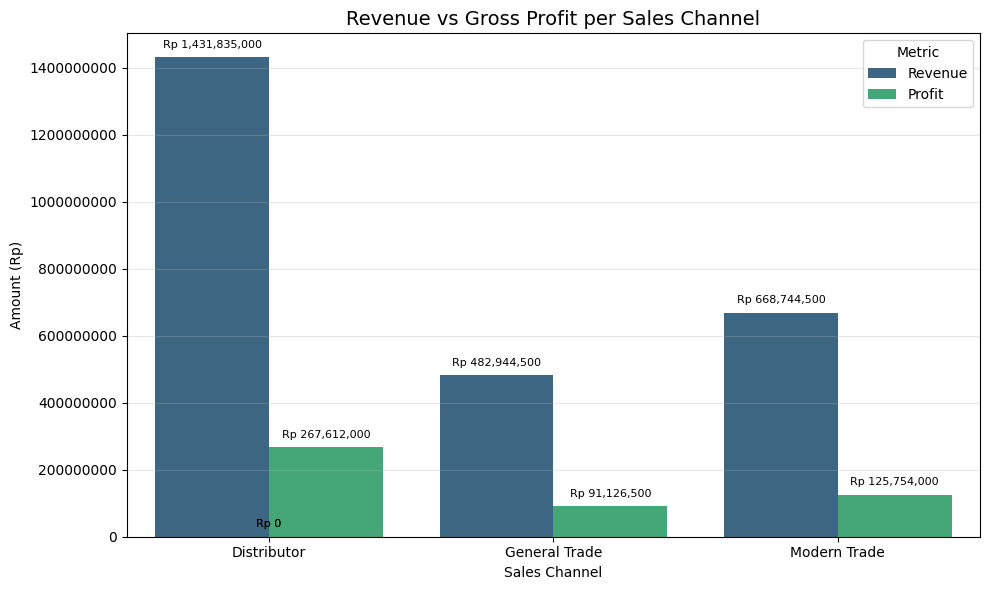

In [ ]:
# 1. Agregasi Revenue dan Profit per Sales Channel
channel_perf = df.groupby('Sales_Channel')[['Revenue', 'Profit']].sum().reset_index()

# 2. Persiapkan data untuk visualisasi (Melting)
channel_viz = channel_perf.melt(id_vars='Sales_Channel', var_name='Metric', value_name='Total_Amount')

# 3. Visualisasi Grouped Bar Chart
plt.figure(figsize=(10, 6))
sns.barplot(data=channel_viz, x='Sales_Channel', y='Total_Amount', hue='Metric', palette='viridis')

# Tambahkan Label Nilai di Atas Bar
for p in plt.gca().patches:
    plt.gca().annotate(f'Rp {p.get_height():,.0f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=8)

plt.title('Revenue vs Gross Profit per Sales Channel', fontsize=14)
plt.xlabel('Sales Channel')
plt.ylabel('Amount (Rp)')
plt.ticklabel_format(style='plain', axis='y')
plt.grid(axis='y', alpha=0.3)
plt.legend(title='Metric')

# 4. Tampilkan Tabel Ringkasan
print("Summary Sales Channel Performance:")
channel_display = channel_perf.copy()
channel_display['Revenue'] = channel_display['Revenue'].apply(lambda x: f"Rp {x:,.0f}")
channel_display['Profit'] = channel_display['Profit'].apply(lambda x: f"Rp {x:,.0f}")
display(channel_display)

plt.tight_layout()
plt.show()

Average Margin per Channel Summary:


,Sales_Channel,Margin_Pct
1,General Trade,17.77%
0,Distributor,17.56%
2,Modern Trade,17.54%


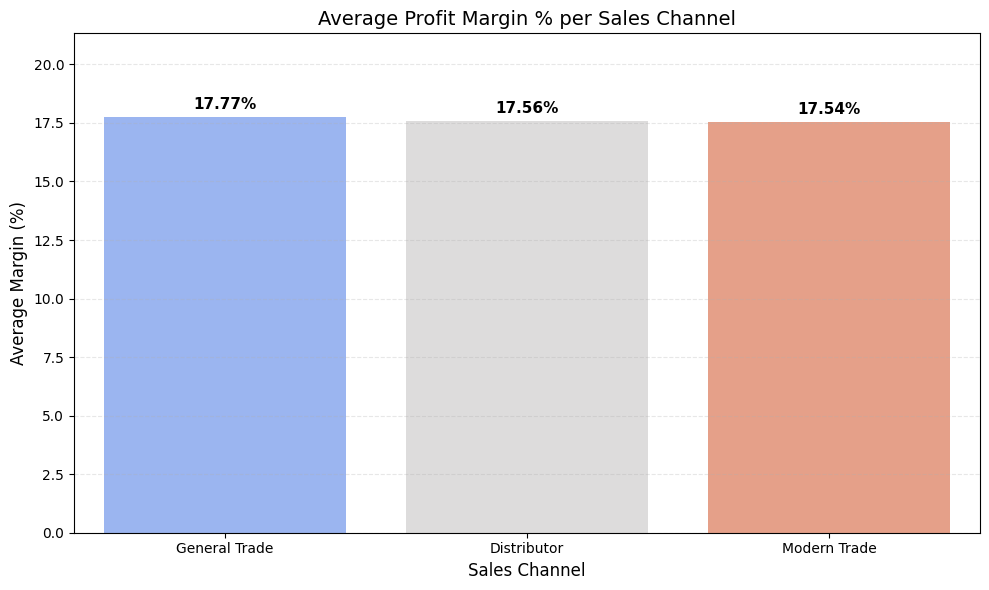

In [ ]:
# Calculate Average Margin % per Sales Channel
channel_margin = df.groupby('Sales_Channel')['Margin_Pct'].mean().reset_index()
channel_margin = channel_margin.sort_values(by='Margin_Pct', ascending=False)

# Visualization
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=channel_margin, x='Sales_Channel', y='Margin_Pct', palette='coolwarm', hue='Sales_Channel', legend=False)

# Add data labels
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=11, weight='bold')

plt.title('Average Profit Margin % per Sales Channel', fontsize=14)
plt.xlabel('Sales Channel', fontsize=12)
plt.ylabel('Average Margin (%)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.ylim(0, channel_margin['Margin_Pct'].max() * 1.2)

# Display summary table
print("Average Margin per Channel Summary:")
display(channel_margin.style.format({'Margin_Pct': '{:.2f}%'}))

plt.tight_layout()
plt.show()

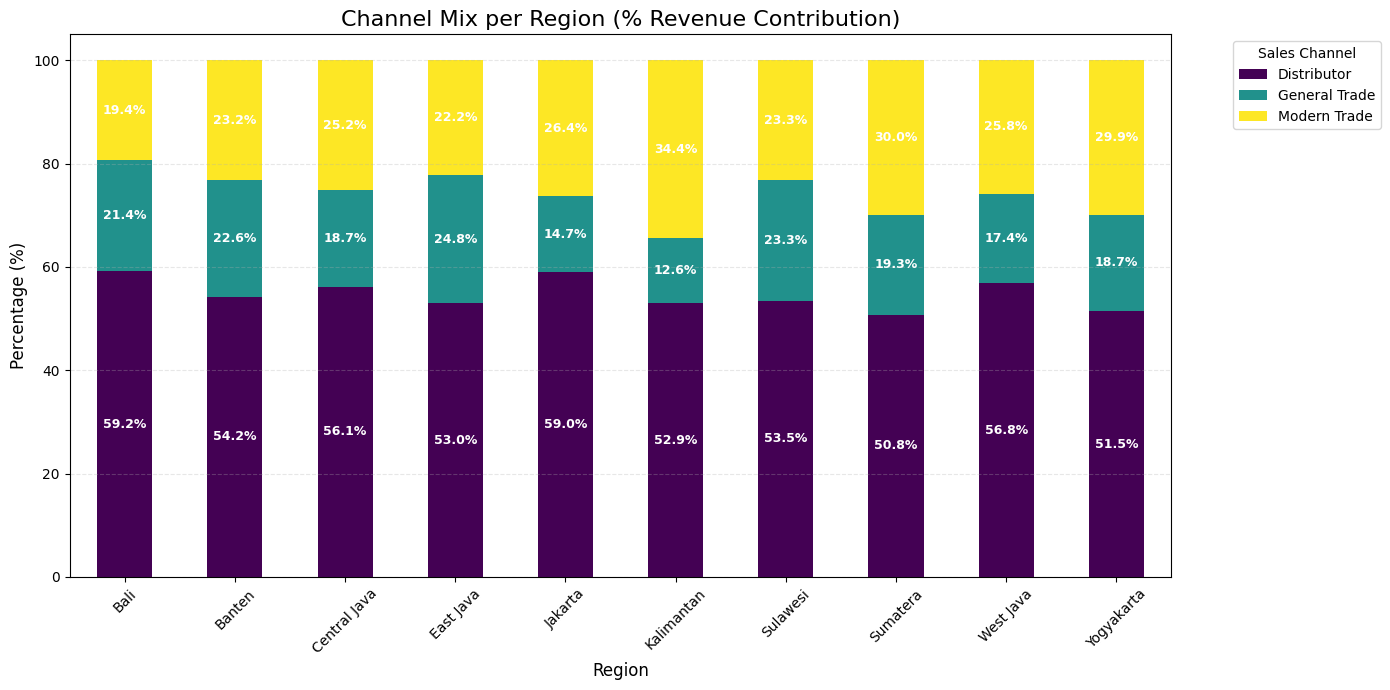

In [ ]:
# 1. Agregasi Revenue per Region dan Sales Channel
channel_mix = df.groupby(['Region', 'Sales_Channel'])['Revenue'].sum().unstack().fillna(0)

# 2. Hitung persentase kontribusi channel per wilayah
channel_mix_pct = channel_mix.div(channel_mix.sum(axis=1), axis=0) * 100

# 3. Visualisasi Stacked Bar Chart
ax = channel_mix_pct.plot(kind='bar', stacked=True, figsize=(14, 7), colormap='viridis')

# Tambahkan label persentase di dalam bar
for n, x in enumerate([*channel_mix_pct.index.values]):
    for (proportion, y_loc) in zip(channel_mix_pct.loc[x],
                                   channel_mix_pct.loc[x].cumsum()):
        if proportion > 5: # Hanya tampilkan label jika proporsinya > 5%
            plt.text(x=n,
                     y=(y_loc - proportion / 2),
                     s=f'{proportion:.1f}%',
                     color='white',
                     fontsize=9,
                     fontweight='bold',
                     ha='center',
                     va='center')

plt.title('Channel Mix per Region (% Revenue Contribution)', fontsize=16)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.legend(title='Sales Channel', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# SKU Portfolio / Pareto

Hasil Pareto Analysis:
- Jumlah SKU yang menyumbang ~80% revenue: 15 dari 25 total SKU
- Persentase SKU 'Core': 60.00%


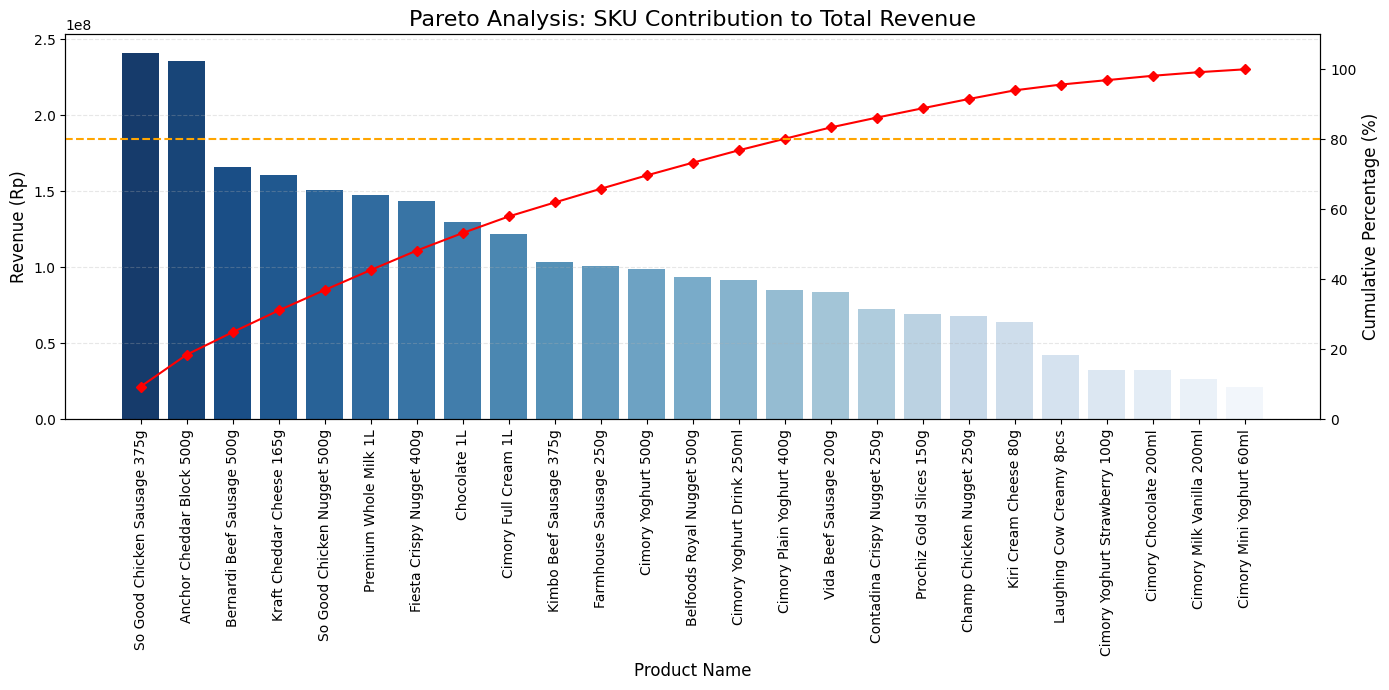

In [ ]:
# 1. Agregasi Revenue per Produk dan Urutkan
pareto_df = df.groupby('Product_Name')['Revenue'].sum().reset_index()
pareto_df = pareto_df.sort_values(by='Revenue', ascending=False)

# 2. Hitung Kumulatif Revenue dan Persentase Kumulatif
pareto_df['Cumulative_Revenue'] = pareto_df['Revenue'].cumsum()
total_revenue = pareto_df['Revenue'].sum()
pareto_df['Cumulative_Pct'] = (pareto_df['Cumulative_Revenue'] / total_revenue) * 100

# 3. Identifikasi SKU yang masuk dalam 80% Revenue
sku_80 = pareto_df[pareto_df['Cumulative_Pct'] <= 81] # Toleransi sedikit di atas 80%
num_sku_80 = len(sku_80)
total_sku = len(pareto_df)
pct_sku_80 = (num_sku_80 / total_sku) * 100

print(f"Hasil Pareto Analysis:")
print(f"- Jumlah SKU yang menyumbang ~80% revenue: {num_sku_80} dari {total_sku} total SKU")
print(f"- Persentase SKU 'Core': {pct_sku_80:.2f}%")

# 4. Visualisasi Pareto Chart
fig, ax1 = plt.subplots(figsize=(14, 7))

# Bar chart untuk Revenue
sns.barplot(x='Product_Name', y='Revenue', data=pareto_df, ax=ax1, palette='Blues_r', hue='Product_Name', legend=False)
ax1.set_ylabel('Revenue (Rp)', fontsize=12)
ax1.set_xlabel('Product Name', fontsize=12)
ax1.tick_params(axis='x', rotation=90)

# Line chart untuk Cumulative Percentage
ax2 = ax1.twinx()
ax2.plot(pareto_df['Product_Name'], pareto_df['Cumulative_Pct'], color='red', marker='D', ms=5, label='Cumulative %')
ax2.axhline(80, color='orange', linestyle='--', label='80% Threshold')
ax2.set_ylabel('Cumulative Percentage (%)', fontsize=12)
ax2.set_ylim(0, 110)

plt.title('Pareto Analysis: SKU Contribution to Total Revenue', fontsize=16)
ax1.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

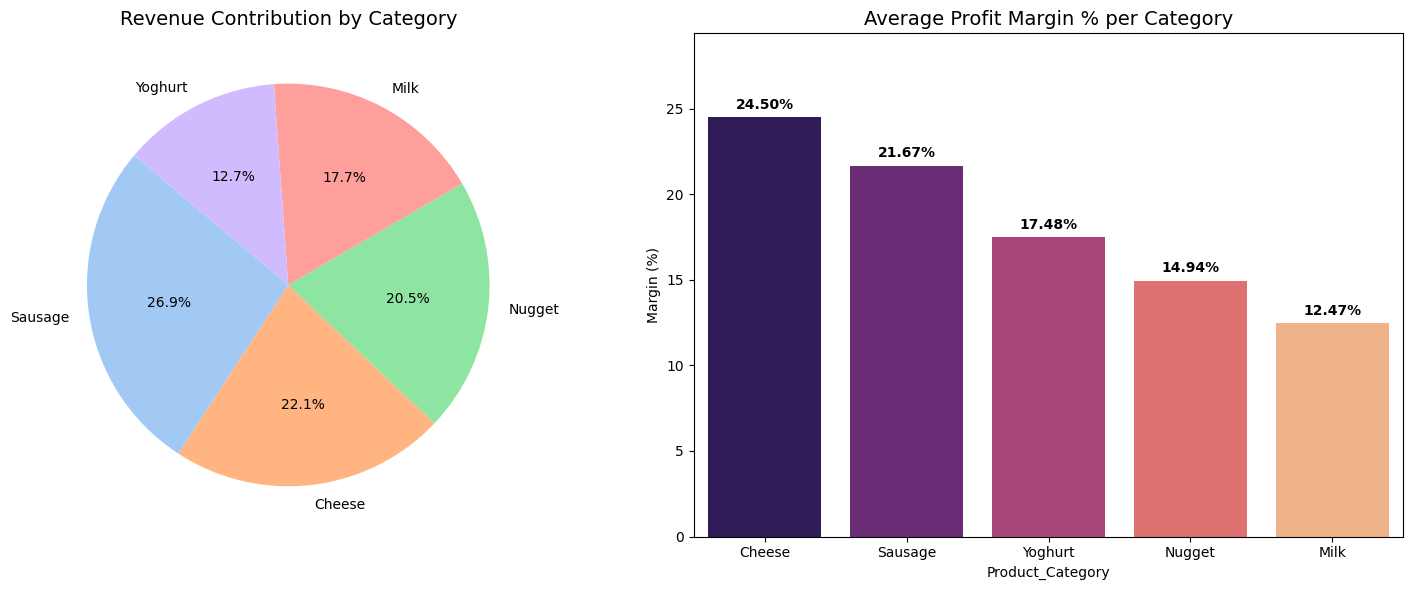

Summary Performance per Category:


,Product_Category,Revenue,Profit,Margin_Pct
0,Cheese,"Rp 571,759,000","Rp 140,069,000",24.497909
1,Sausage,"Rp 695,620,000","Rp 150,708,000",21.665277
2,Yoghurt,"Rp 329,374,000","Rp 57,588,500",17.484228
3,Nugget,"Rp 528,553,500","Rp 78,973,500",14.941439
4,Milk,"Rp 458,217,500","Rp 57,153,500",12.473007


In [ ]:
# 1. Agregasi Revenue dan Profit per Kategori
category_perf = df.groupby('Product_Category')[['Revenue', 'Profit']].sum().reset_index()
category_perf = category_perf.sort_values(by='Revenue', ascending=False)

# 2. Visualisasi Kontribusi Revenue (Pie Chart)
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.pie(category_perf['Revenue'], labels=category_perf['Product_Category'], autopct='%1.1f%%',
        startangle=140, colors=sns.color_palette('pastel'))
plt.title('Revenue Contribution by Category', fontsize=14)

# 3. Visualisasi Profit Margin per Kategori (Bar Chart)
plt.subplot(1, 2, 2)
category_perf['Margin_Pct'] = (category_perf['Profit'] / category_perf['Revenue']) * 100
category_perf = category_perf.sort_values(by='Margin_Pct', ascending=False)

ax = sns.barplot(data=category_perf, x='Product_Category', y='Margin_Pct', palette='magma', hue='Product_Category', legend=False)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points', weight='bold')

plt.title('Average Profit Margin % per Category', fontsize=14)
plt.ylabel('Margin (%)')
plt.ylim(0, category_perf['Margin_Pct'].max() * 1.2)

plt.tight_layout()
plt.show()

# 4. Ringkasan Tabel
print("Summary Performance per Category:")
category_display = category_perf.copy()
category_display['Revenue'] = category_display['Revenue'].apply(lambda x: f"Rp {x:,.0f}")
category_display['Profit'] = category_display['Profit'].apply(lambda x: f"Rp {x:,.0f}")
display(category_display[['Product_Category', 'Revenue', 'Profit', 'Margin_Pct']].reset_index(drop=True))

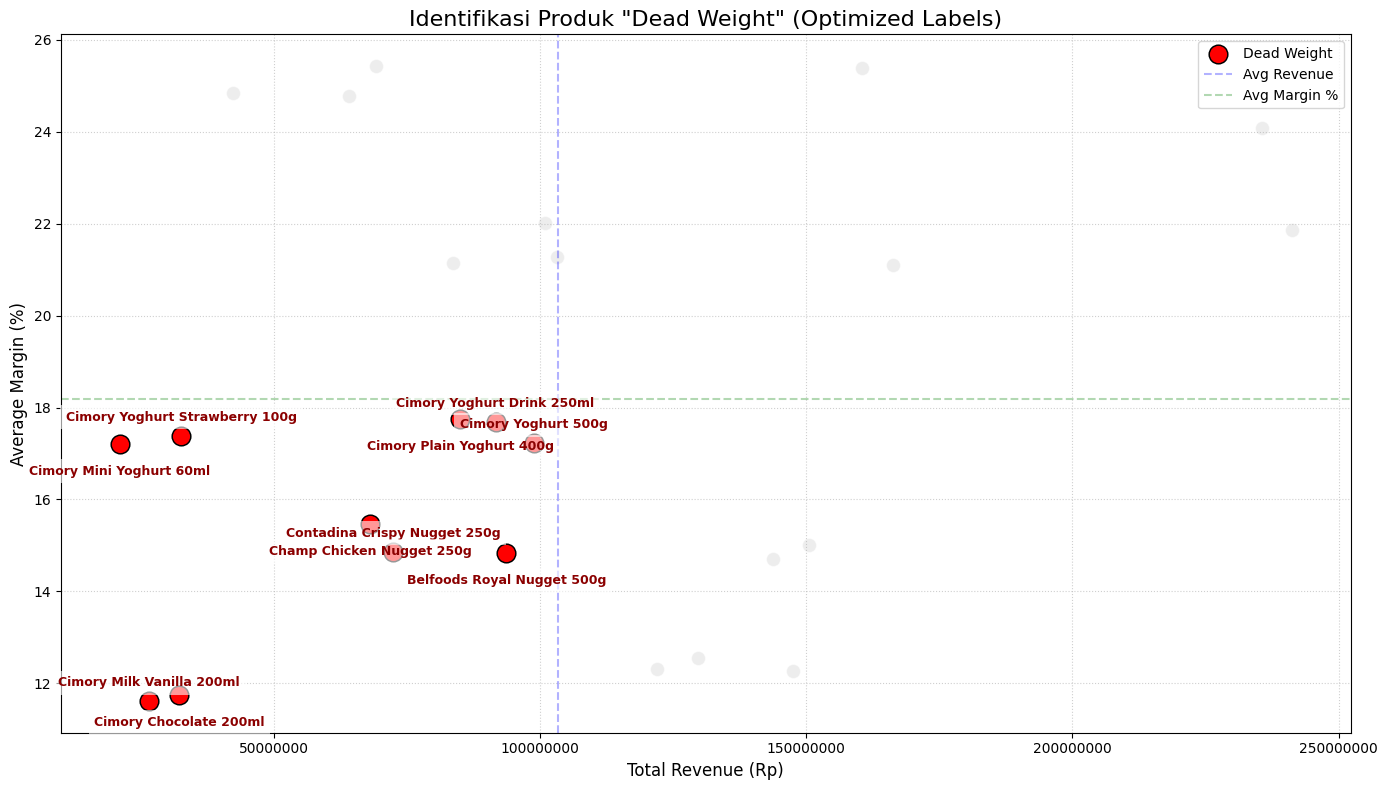

Daftar Produk 'Dead Weight' (Total: 10 produk):


,Product_Name,Revenue,Margin_Pct
0,Cimory Yoghurt 500g,"Rp 98,853,500",17.23%
1,Belfoods Royal Nugget 500g,"Rp 93,720,000",14.84%
2,Cimory Yoghurt Drink 250ml,"Rp 91,679,500",17.69%
3,Cimory Plain Yoghurt 400g,"Rp 85,052,000",17.75%
4,Contadina Crispy Nugget 250g,"Rp 72,388,000",14.86%
5,Champ Chicken Nugget 250g,"Rp 68,159,000",15.48%
6,Cimory Yoghurt Strawberry 100g,"Rp 32,694,000",17.39%
7,Cimory Chocolate 200ml,"Rp 32,296,500",11.75%
8,Cimory Milk Vanilla 200ml,"Rp 26,528,500",11.61%
9,Cimory Mini Yoghurt 60ml,"Rp 21,095,000",17.22%


In [ ]:
# 1. Tentukan threshold berdasarkan rata-rata
avg_revenue = product_matrix['Revenue'].mean()
avg_margin = product_matrix['Margin_Pct'].mean()

# 2. Identifikasi produk 'Dead Weight'
dead_weight_products = product_matrix[
    (product_matrix['Revenue'] < avg_revenue) &
    (product_matrix['Margin_Pct'] < avg_margin)
].sort_values(by='Revenue', ascending=False).reset_index(drop=True)

# 3. Visualisasi dengan Label yang Diperbaiki agar Tidak Tertumpuk
plt.figure(figsize=(14, 8))
sns.scatterplot(data=product_matrix, x='Revenue', y='Margin_Pct', s=100, color='lightgrey', alpha=0.4)

# Highlight dead weight
sns.scatterplot(data=dead_weight_products, x='Revenue', y='Margin_Pct', s=180, color='red', label='Dead Weight', edgecolor='black')

# Tambahkan label dengan offset vertikal yang bergantian agar tidak bertumpukan
for i, row in dead_weight_products.iterrows():
    # Logika sederhana: ganti posisi teks ke atas atau bawah secara bergantian
    offset_y = 0.4 if i % 2 == 0 else -0.6
    plt.text(row['Revenue'], row['Margin_Pct'] + offset_y, row['Product_Name'],
             fontsize=9, fontweight='bold', color='darkred',
             ha='center', va='center', bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

plt.axvline(avg_revenue, color='blue', linestyle='--', alpha=0.3, label='Avg Revenue')
plt.axhline(avg_margin, color='green', linestyle='--', alpha=0.3, label='Avg Margin %')

plt.title('Identifikasi Produk "Dead Weight" (Optimized Labels)', fontsize=16)
plt.xlabel('Total Revenue (Rp)', fontsize=12)
plt.ylabel('Average Margin (%)', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.ticklabel_format(style='plain', axis='x')
plt.tight_layout()
plt.show()

# 4. Tampilkan Daftar Produk
print(f"Daftar Produk 'Dead Weight' (Total: {len(dead_weight_products)} produk):")
dead_weight_display = dead_weight_products.copy()
dead_weight_display['Revenue'] = dead_weight_display['Revenue'].apply(lambda x: f"Rp {x:,.0f}")
dead_weight_display['Margin_Pct'] = dead_weight_display['Margin_Pct'].apply(lambda x: f"{x:.2f}%")
display(dead_weight_display)

# Customer Segmentation

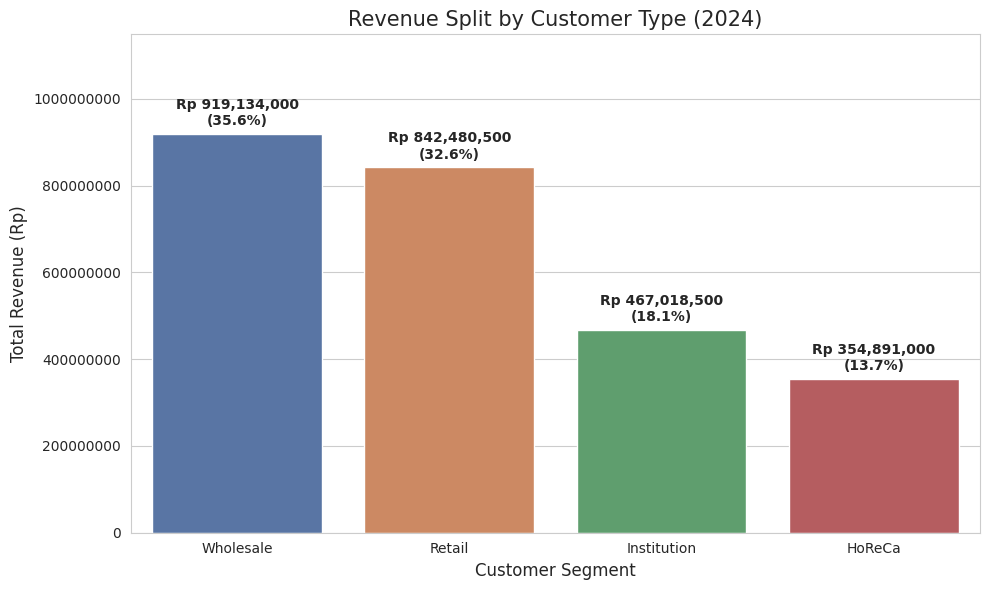

Summary Customer Type Split:


,Customer_Type,Revenue,Contribution (%)
3,Wholesale,"Rp 919,134,000",35.58%
2,Retail,"Rp 842,480,500",32.61%
1,Institution,"Rp 467,018,500",18.08%
0,HoReCa,"Rp 354,891,000",13.74%


In [ ]:
# 1. Agregasi Revenue per Customer Type
customer_split = df.groupby('Customer_Type')['Revenue'].sum().reset_index()
customer_split = customer_split.sort_values(by='Revenue', ascending=False)

# 2. Hitung persentase kontribusi
total_rev = customer_split['Revenue'].sum()
customer_split['Contribution (%)'] = (customer_split['Revenue'] / total_rev) * 100

# 3. Visualisasi Revenue Split
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax = sns.barplot(data=customer_split, x='Customer_Type', y='Revenue', palette='deep', hue='Customer_Type', legend=False)

# Tambahkan label nilai nominal dan persentase
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'Rp {height:,.0f}\n({(height/total_rev*100):.1f}%)',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='center', xytext=(0, 15),
                textcoords='offset points', fontsize=10, weight='bold')

plt.title('Revenue Split by Customer Type (2024)', fontsize=15)
plt.ylabel('Total Revenue (Rp)', fontsize=12)
plt.xlabel('Customer Segment', fontsize=12)
plt.ticklabel_format(style='plain', axis='y')
plt.ylim(0, customer_split['Revenue'].max() * 1.25)

plt.tight_layout()
plt.show()

# 4. Tampilkan Tabel Ringkasan
print("Summary Customer Type Split:")
display(customer_split.style.format({'Revenue': 'Rp {:,.0f}', 'Contribution (%)': '{:.2f}%'}))

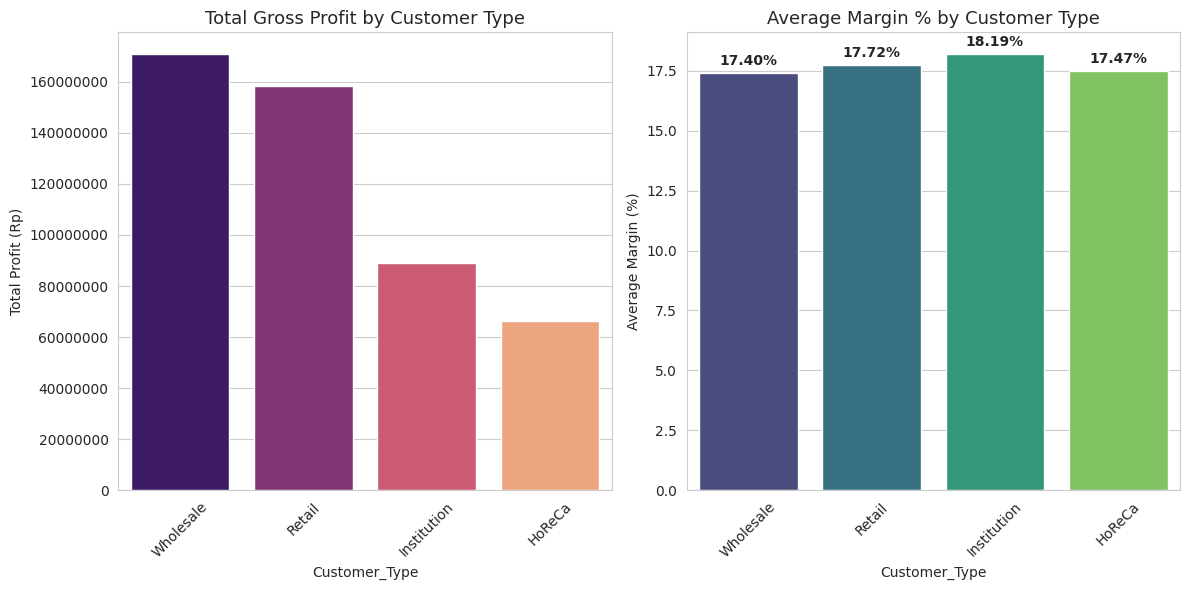

Summary Profitability per Customer Segment:


,Customer_Type,Profit,Margin_Pct
0,Wholesale,"Rp 170,850,000",17.40%
1,Retail,"Rp 158,473,000",17.72%
2,Institution,"Rp 88,907,000",18.19%
3,HoReCa,"Rp 66,262,500",17.47%


In [ ]:
# 1. Agregasi Profit dan Rata-rata Margin per Customer Type
customer_profit = df.groupby('Customer_Type').agg({
    'Profit': 'sum',
    'Margin_Pct': 'mean'
}).reset_index()

# Urutkan berdasarkan Profit
customer_profit = customer_profit.sort_values(by='Profit', ascending=False)

# 2. Visualisasi Profit per Customer Type
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
ax1 = sns.barplot(data=customer_profit, x='Customer_Type', y='Profit', palette='magma', hue='Customer_Type', legend=False)
plt.title('Total Gross Profit by Customer Type', fontsize=13)
plt.ylabel('Total Profit (Rp)')
plt.xticks(rotation=45)
plt.ticklabel_format(style='plain', axis='y')

# 3. Visualisasi Average Margin per Customer Type
plt.subplot(1, 2, 2)
ax2 = sns.barplot(data=customer_profit, x='Customer_Type', y='Margin_Pct', palette='viridis', hue='Customer_Type', legend=False)
plt.title('Average Margin % by Customer Type', fontsize=13)
plt.ylabel('Average Margin (%)')
plt.xticks(rotation=45)

# Tambahkan label persentase
for p in ax2.patches:
    ax2.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points', weight='bold')

plt.tight_layout()
plt.show()

# 4. Tampilkan Tabel Ringkasan
print("Summary Profitability per Customer Segment:")
customer_profit_display = customer_profit.copy()
customer_profit_display['Profit'] = customer_profit_display['Profit'].apply(lambda x: f"Rp {x:,.0f}")
customer_profit_display['Margin_Pct'] = customer_profit_display['Margin_Pct'].apply(lambda x: f"{x:.2f}%")
display(customer_profit_display.reset_index(drop=True))

<Figure size 1200x700 with 0 Axes>

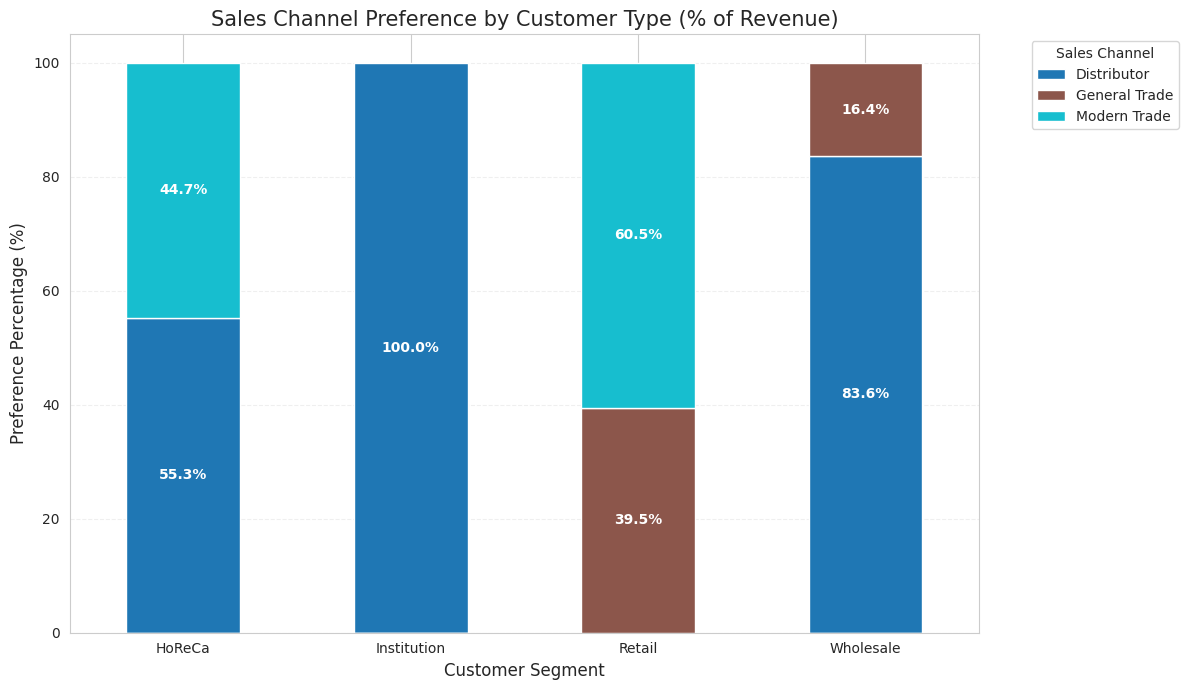

Revenue Distribution per Channel (in Million Rp):


Sales_Channel,Distributor,General Trade,Modern Trade
Customer_Type,,,
HoReCa,196.24M,0.00M,158.65M
Institution,467.02M,0.00M,0.00M
Retail,0.00M,332.39M,510.09M
Wholesale,768.58M,150.55M,0.00M


In [ ]:
# 1. Agregasi Revenue berdasarkan Customer Type dan Sales Channel
customer_channel_pref = df.groupby(['Customer_Type', 'Sales_Channel'])['Revenue'].sum().unstack().fillna(0)

# 2. Hitung persentase preferensi channel untuk tiap Customer Type
customer_channel_pct = customer_channel_pref.div(customer_channel_pref.sum(axis=1), axis=0) * 100

# 3. Visualisasi Stacked Bar Chart
plt.figure(figsize=(12, 7))
ax = customer_channel_pct.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='tab10')

# Tambahkan label persentase
for n, x in enumerate([*customer_channel_pct.index.values]):
    for (proportion, y_loc) in zip(customer_channel_pct.loc[x],
                                   customer_channel_pct.loc[x].cumsum()):
        if proportion > 1: # Tampilkan jika kontribusi > 1%
            plt.text(x=n,
                     y=(y_loc - proportion / 2),
                     s=f'{proportion:.1f}%',
                     color='white',
                     fontsize=10,
                     fontweight='bold',
                     ha='center',
                     va='center')

plt.title('Sales Channel Preference by Customer Type (% of Revenue)', fontsize=15)
plt.xlabel('Customer Segment', fontsize=12)
plt.ylabel('Preference Percentage (%)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Sales Channel', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# 4. Tabel Ringkasan (Nominal)
print("Revenue Distribution per Channel (in Million Rp):")
display((customer_channel_pref / 1000000).style.format("{:,.2f}M"))

In [ ]:
import pandas as pd

# 1. Agregasi metrik utama per wilayah
regional_summary = df.groupby('Region').agg({
    'Revenue': 'sum',
    'Profit': 'sum',
    'Margin_Pct': 'mean'
}).reset_index()

# 2. Urutkan berdasarkan Revenue tertinggi
regional_summary = regional_summary.sort_values(by='Revenue', ascending=False)

# 3. Hitung kontribusi revenue terhadap total nasional
total_rev_nat = regional_summary['Revenue'].sum()
regional_summary['Contribution (%)'] = (regional_summary['Revenue'] / total_rev_nat) * 100

# 4. Format tampilan tabel
regional_summary_display = regional_summary.copy()
regional_summary_display['Revenue'] = regional_summary_display['Revenue'].apply(lambda x: f"Rp {x:,.0f}")
regional_summary_display['Profit'] = regional_summary_display['Profit'].apply(lambda x: f"Rp {x:,.0f}")
regional_summary_display['Margin_Pct'] = regional_summary_display['Margin_Pct'].apply(lambda x: f"{x:.2f}%")
regional_summary_display['Contribution (%)'] = regional_summary_display['Contribution (%)'].apply(lambda x: f"{x:.2f}%")

print("Tabel Ringkasan Kinerja Penjualan per Wilayah (Lengkap):")
display(regional_summary_display.reset_index(drop=True))

Tabel Ringkasan Kinerja Penjualan per Wilayah (Lengkap):


,Region,Revenue,Profit,Margin_Pct,Contribution (%)
0,Jakarta,"Rp 531,247,500","Rp 99,725,000",17.89%,20.56%
1,West Java,"Rp 410,571,000","Rp 76,613,500",17.95%,15.89%
2,Central Java,"Rp 324,115,000","Rp 61,033,500",17.85%,12.55%
3,East Java,"Rp 312,803,500","Rp 57,982,000",17.12%,12.11%
4,Sumatera,"Rp 231,373,000","Rp 43,061,500",17.42%,8.96%
5,Kalimantan,"Rp 186,348,500","Rp 34,283,500",17.33%,7.21%
6,Banten,"Rp 179,652,000","Rp 32,570,000",17.44%,6.95%
7,Bali,"Rp 154,602,500","Rp 30,646,000",17.86%,5.98%
8,Sulawesi,"Rp 139,861,000","Rp 26,597,500",17.04%,5.41%
9,Yogyakarta,"Rp 112,950,000","Rp 21,980,000",18.29%,4.37%


### **EXECUTIVE SUMMARY: FMCG SALES & PROFITABILITY ANALYSIS 2024**

#### **1. Key Financial Highlights**
*   **Revenue Growth:** Total annual revenue peaked in **December (Rp 394.7M)**, showing strong end-of-year seasonality.
*   **Profitability:** Average gross margin across the portfolio is approximately **18%**, with **Cheese (24.5%)** and **Sausage (21.7%)** being the most profitable categories.
*   **Top Performers:** *So Good Chicken Sausage 375g* is the revenue leader, while *Anchor Cheddar Block 500g* is the single most profitable SKU.

#### **2. Regional & Channel Insights**
*   **Dominant Market:** **Jakarta** accounts for over **20%** of total revenue. **West Java** follows as a strong second.
*   **Channel Efficiency:** **Distributors** handle the highest volume (55% of revenue), but **General Trade** offers slightly higher average margins (17.77%).
*   **Customer Segmentation:** **Wholesale** and **Retail** are the primary drivers (combined ~68% of revenue). Interestingly, **Institutions** have the highest margin discipline at **18.19%**.

#### **3. Portfolio Health (Pareto & Matrix)**
*   **Efficiency Gap:** 60% of SKUs (15 items) generate 80% of revenue. The remaining 40% of the portfolio needs review.
*   **Dead Weight:** identified 10 products (mostly small-format Dairy/Milk) with both low revenue and low margins. These are likely diluting overall operational focus.

---

### **STRATEGIC RECOMMENDATIONS**

**A. Portfolio Optimization (Rationalization)**
*   **Action:** Conduct a delisting or rebranding exercise for the identified "Dead Weight" products, particularly the underperforming Cimory small-format items (60ml - 250ml).
*   **Goal:** Reallocate shelf space and marketing budget toward high-margin "Star" products like Anchor Cheddar and So Good Sausage.

**B. Targeted Regional Expansion**
*   **Action:** Incentivize growth in high-potential but lower-revenue regions like **Yogyakarta** and **Bali**, which already show healthy profit margins (>17.8%).
*   **Goal:** Diversify revenue streams beyond the Jakarta/West Java core.

**C. Channel & Customer Strategy**
*   **Action:** Strengthen the Institutional pipeline since it offers the best margins and is currently 100% dependent on Distributors. Explore direct partnerships for high-volume institutions.
*   **Action:** For the **Retail** segment, continue focusing on **Modern Trade** (their preferred channel) but introduce high-margin Sausage/Cheese bundles to capitalize on their 17.7% average margin.

**D. Inventory & Seasonality Management**
*   **Action:** Increase safety stock and marketing spend starting in **November** to capture the massive **December** peak.
*   **Goal:** Prevent stock-outs during the highest-earning month of the year.